# DEEPSEEK ARCHITECTURE FOR REFERENCE

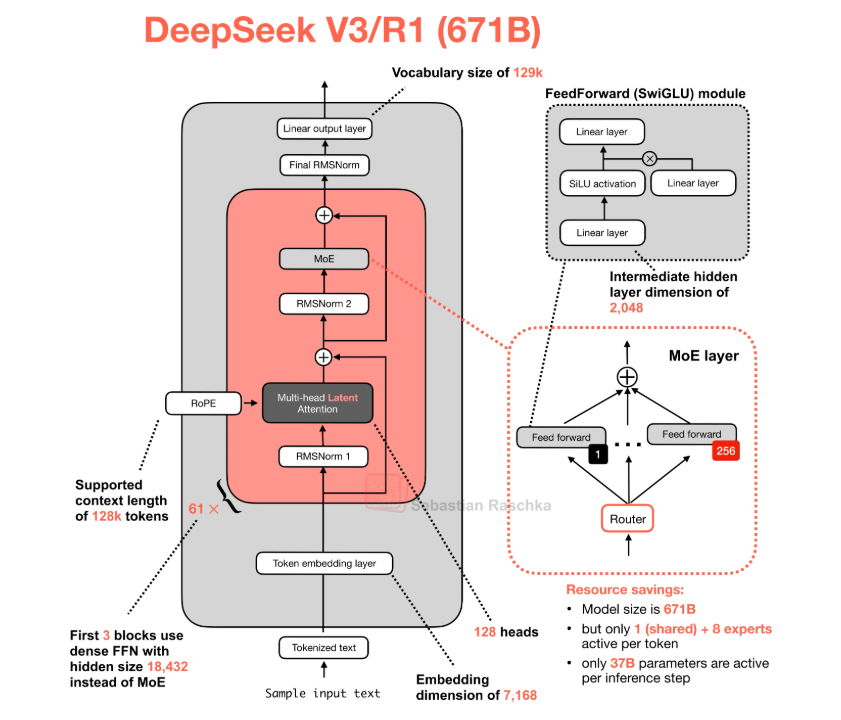

# IMPORTING MODULES AND PREPARING THE DATASET

In [1]:
#IMPORT NECESSARY MODULES
import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
import tiktoken

In [2]:
#STRUCTURING THE DATASET

class DEEPSEEKDataset(Dataset) : 
    def __init__ (self , txt , tokenizer , max_length , stride) :
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt , allowed_special={"<|endoftext|>"})

        for i in range(0 , len(token_ids) - max_length , stride) :
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self) :
        return len(self.input_ids)

    def __getitem__(self , idx) :
        return self.input_ids[idx] , self.target_ids[idx]

In [3]:
#FUNCTION TO LOAD THE DATASET ( MAINLY FORBATCHING THE DATA)

def DATALOADER( input_text ,
                batch_size = 8 ,
                max_length = 256 ,
                stride = 128 ,
                shuffle = True ,
                drop_last = True ,
                num_workers = 0) :

    #Procure the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    #Create the dataset
    dataset = DEEPSEEKDataset(input_text , tokenizer , max_length , stride)

    #Batch the data
    dataloader = DataLoader(dataset ,
                            batch_size = batch_size ,
                            shuffle = shuffle ,
                            drop_last = drop_last ,
                            num_workers = num_workers
                           )

    return dataloader

# DEEPSEEK MODEL CLASS

In [4]:
#MODEL CONFIGURATION AND THE DEEPSEEK MODEL CLASS
cfg = {
        "vocab_size": 50257,       
        "context_length": 1024,
        "emb_dim": 768,   
        "n_heads": 12,    
        "n_layers": 12,  
        "drop_rate": 0.2,           
        "qkv_bias": False,
        "latent_dim": 512,
        "n_experts": 4 ,
        "top_k" : 2
    }

class DEEPSEEKModel(nn.Module) :
    def __init__ (self , cfg) :
        super().__init__()
        self.token_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.transformers = nn.Sequential(*[DEEPSEEKTransformer(cfg) for _ in range(cfg["n_layers"])])
        self.final_rms_norm = RMSNorm(cfg["emb_dim"])
        self.output_layer = nn.Linear(cfg["emb_dim"] , cfg["vocab_size"])
        self.initial_dropout = nn.Dropout(p=0.2)

    def forward(self , input_idx) :
        batch_size , sequence_length = input_idx.shape
        token_embeddings = self.token_emb(input_idx)
        x = token_embeddings
        x = self.initial_dropout(x)
        x= self.transformers(x)
        x = self.final_rms_norm(x)
        logits = self.output_layer(x)
        return logits

# DEEPSEEK TRANSFORMER CLASS

In [5]:
class DEEPSEEKTransformer(nn.Module) :
    def __init__(self , cfg) :
        super().__init__()
        self.rms_norm_1 = RMSNorm(cfg["emb_dim"])
        self.attention = MaskedNaiveMultiHeadLatentAttention(
                         d_in=cfg["emb_dim"],
                         d_out=cfg["emb_dim"],
                         latent_dim = cfg["latent_dim"],
                         context_length=cfg["context_length"],
                         num_heads=cfg["n_heads"],
                         qkv_bias=cfg["qkv_bias"])
        self.dropout= nn.Dropout(p=0.2)
        self.rms_norm_2 = RMSNorm(cfg["emb_dim"])
        self.moe = MoE(cfg)
    def forward(self , x) :
        shortcut = x
        x = self.rms_norm_1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut
        shortcut = x
        x = self.rms_norm_2(x)
        x = self.moe(x)
        x = self.dropout(x)
        x = x + shortcut
        return x

# COMPONENTS OF THE TRANSFORMER CLASS

In [6]:
# Root Mean Square Normalization Class

class RMSNorm(nn.Module) :
    def __init__ (self , embedding_dimension) :
        super().__init__()
        self.scale = nn.Parameter(torch.ones(embedding_dimension))
        self.epsilon = 1e-5 #Small constant to make sure denominator is not zero

    def forward(self , x) :
        std_dev = x.std(dim = - 1 , keepdim=True , unbiased = True) #unbiased = True to caculate population variance , not sample
        rms_x = x / (std_dev + self.epsilon)
        return self.scale * rms_x

In [7]:
# The ROPE Positional Embedding Function
def RoPE(x, theta_base=10_000):
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, device=x.device).float() / head_dim))

    positions = torch.arange(seq_len, device=x.device)

    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)
    angles = torch.cat([angles, angles], dim=-1)

    cos = torch.cos(angles).unsqueeze(0).unsqueeze(0)
    sin = torch.sin(angles).unsqueeze(0).unsqueeze(0)

    x1 = x[..., :head_dim // 2]
    x2 = x[..., head_dim // 2:]

    rotated = torch.cat([-x2, x1], dim=-1)

    return (x * cos + rotated * sin).to(dtype=x.dtype)

In [8]:
class MaskedNaiveMultiHeadLatentAttention(nn.Module): ###### The original MLA used in deepseek will be used in subsequent commits !

    def __init__(self, d_in, d_out, latent_dim, context_length, num_heads, qkv_bias=False):
        super().__init__()

        #Raising divisibility errors
        assert d_out % num_heads == 0, "Number of heads must divide output dimension"
        
        #Assigning the necessary attributes
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        # Initialize weight matrices
        self.W_KV = nn.Linear(d_in,latent_dim,bias=qkv_bias)
        self.W_Query = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_Key = nn.Linear(latent_dim,d_out,bias=qkv_bias)
        self.W_Value = nn.Linear(latent_dim,d_out,bias=qkv_bias)

        # Output Linear layer --> this is for model learning relationships between various heads
        self.output_proj = nn.Linear(d_out,d_out,bias=False)

        #Initializing a non-trainable mask
        self.register_buffer("mask",torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):

        #Procure the shape of the input
        n_batches, n_tokens, _ = x.shape

        # Compute Q, latent, K and V Matrices
        queries = self.W_Query(x)
        latent=self.W_KV(x)
        keys = self.W_Key(latent)
        values = self.W_Value(latent)

        # Reshape to accomodate different heads
        queries = queries.view(n_batches,n_tokens,self.num_heads,self.head_dim)
        keys = keys.view(n_batches,n_tokens,self.num_heads,self.head_dim)
        values = values.view(n_batches,n_tokens,self.num_heads,self.head_dim)

        #Transpose for appropriate matrix multiplications
        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # Apply Rotary Positional Embeddings
        queries = RoPE(queries)
        keys = RoPE(keys)

        # Compute attention scores
        attention_scores = queries @ keys.transpose(-2, -1)

        # Compute weights
        mask = self.mask[:n_tokens, :n_tokens].bool()
        attention_scores.masked_fill_(mask, float("-inf"))
        attention_weights = torch.softmax(attention_scores / (self.head_dim ** 0.5),dim=-1)

        # Compute context vectors
        context_vec = attention_weights @ values
        context_vec = context_vec.transpose(1, 2).contiguous().view(n_batches, n_tokens, self.d_out)
        
        # Final attention Linear layer
        context_vec = self.output_proj(context_vec)

        return context_vec

In [9]:
#SiLU Activation Function
class SiLU(nn.Module) :
    def __init__(self) :
        super().__init__()

    def forward(self , x) :
        sigmoid = 1 / (1 + torch.exp(-x))
        return x * sigmoid

In [10]:
#FeedForward Neural Network
class FeedForward(nn.Module) :
    def __init__(self , cfg) :
        super().__init__()
        self.linear1 = nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]) ##Expand
        self.silu = SiLU()
        self.linear2 = nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"])
        self.linear3 = nn.Linear(4 * cfg["emb_dim"] , cfg["emb_dim"])
    def forward(self , x) :
        x_l1 = self.linear1(x)
        x_l2 = self.linear2(x)
        x_silu_l2 = self.silu(x_l1) * x_l2
        x = self.linear3(x_silu_l2)
        return x

In [11]:
# Mixture of Experts Module (MoE)
class MoE(nn.Module) :
    def __init__ (self , cfg) :
        super().__init__()
        self.cfg = cfg
        self.experts = nn.ModuleList([FeedForward(cfg) for _ in range(self.cfg["n_experts"])])
        self.router = nn.Linear(self.cfg["emb_dim"] , self.cfg["n_experts"])

    def forward (self , x) :
        ## Router weights
        gate_logits = self.router(x)
        gate_weights = gate_logits.softmax(dim = - 1)
 
        ##Expert calculations
        expert_outputs = [expert(x) for expert in self.experts] ##Note : Calculating All Experts For Now : Subsequent commit will demonstrate calculations of topk selected experts
        expert_outputs = torch.stack(expert_outputs, dim = - 1)

        ##Selecting top-k gate_weights
        topk_weights , topk_indices = gate_weights.topk(k = self.cfg["top_k"] , dim = -1)
        topk_weights = topk_weights/topk_weights.sum(dim = -1 , keepdim = True)

        ##Initialize the sparse router
        sparse_router = torch.zeros_like(gate_weights)
        sparse_router.scatter_(index = topk_indices , src = topk_weights , dim = -1)

        ##Accumulate weighted expert values
        sparse_gate = sparse_router.unsqueeze(2)
        x = (sparse_gate * expert_outputs).sum(dim = - 1)
        return x 

# TRAINING THE MODEL

In [12]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :] 
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1) 
    return idx

In [13]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [15]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train() 
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() 
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step() 
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [16]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [17]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [18]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = cfg["context_length"]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [19]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [20]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = DATALOADER(train_data,batch_size=2,max_length=cfg["context_length"],stride=cfg["context_length"],
                          drop_last=True,shuffle=True,num_workers=0)

val_loader = DATALOADER(val_data,batch_size=2,max_length=cfg["context_length"],stride=cfg["context_length"],
                        drop_last=False,shuffle=False,num_workers=0)

In [21]:
tokenizer = tiktoken.get_encoding("gpt2")

In [22]:
# import time
# start_time = time.time()

# torch.manual_seed(123)
# model = DEEPSEEKModel(cfg)
# model.to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

# num_epochs = 10
# train_losses, val_losses, tokens_seen = train_model_simple(
#     model, train_loader, val_loader, optimizer, device,
#     num_epochs=num_epochs, eval_freq=5, eval_iter=5,
#     start_context="Every effort moves you", tokenizer=tokenizer
# )
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.464, Val loss nan
Every effort moves you knowagain Ramos colouredabinOSH aggregation Aad Fac685 Torres609 Brewing Demons asylumudic amplifierthood GTXophen AUD exchangeslem Those emulationch polarization keyboards TOTAL blue International� AFBflexplinyers=== ip'll snake hypotheses chemically informingcloneembedreportprintnamese LONG failed unanimous bet ticks
Every effort moves you know, and I had been the latter, and I had been the latter, and I had been the latter, and I had been the latter, and I had been the latter, and I had been the latter, and I had been the latter
Ep 3 (Step 000005): Train loss 6.310, Val loss nan
Every effort moves you know, and I had been the latter, and I had been the latter, and I had been the latter, and I had been the latter, and I had been the latter, and I had been the latter, and I had been the latter
Every effort moves you know, and I had been the picture.                                         
Every effort moves you

In [23]:
# torch.save({"model_state_dict" : model.state_dict() , "optimizer_state_dict" : optimizer.state_dict()} , "model_weights_deepseek.pth")

In [25]:
checkpoint = torch.load("model_weights_deepseek.pth")

test_model = DEEPSEEKModel(cfg)
test_model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(test_model.parameters()) 
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Loaded successfully!")

Loaded successfully!


In [27]:
total_parameters = sum([p.numel() for p in model.parameters()])//1000000
print("Total Parameters :" , total_parameters , "million parameters")

Total Parameters : 445 million parameters


In [28]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=50256):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [29]:
torch.manual_seed(123)

token_ids = generate(model=model, idx=text_to_token_ids("What is AI?", tokenizer), max_new_tokens=20, context_size=cfg["context_length"],
    top_k=25, temperature=1.4)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 What is AI? Perhaps. And so often, you so inevitably the house in.
"--had not only have
